[Zomato Data Analysis](https://)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [5]:
df = pd.read_csv("/content/zomato.csv")
print(df.head(5))

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate votes                             phone  \
0          Yes        Yes  4.1/5   775    080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5   787                      080 41714161   
2          Yes         No  3.8/5   918                    +91 9663487993   
3           No         No  3.7/5    88                    +91 9620009302   
4           No         No  3.8/5   166  +91 8026612447\r\n+91 9901210005   

       location            rest_type  \
0  Banashankari        Casua

In [13]:
df['restaurant_name'] = df['name'].str.lower().str.strip()
df['cuisine'] = df['cuisines'].str.lower()
df.isnull().sum()

conversion_rate = 83
# Clean and convert 'approx_cost(for two people)' to numeric
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

df['price_inr'] = df['approx_cost(for two people)'] * conversion_rate
warnings.filterwarnings("ignore")
df

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type),restaurant_name,cuisine,price_inr,rating
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet,jalsa,"north indian, mughlai, chinese",66400.0,4.1
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet,spice elephant,"chinese, north indian, thai",66400.0,4.1
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet,san churro cafe,"cafe, mexican, italian",66400.0,3.8
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Buffet,addhuri udupi bhojana,"south indian, north indian",24900.0,3.7
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet,grand village,"north indian, rajasthani",49800.0,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56247,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,1500.0,Pubs and bars,best brews - four points by sheraton bengaluru...,continental,124500.0,3.6
56248,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600.0,Pubs and bars,vinod bar and restaurant,finger food,49800.0,NaN
56249,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,2000.0,Pubs and bars,plunge - sheraton grand bengaluru whitefield h...,finger food,166000.0,NaN
56250,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2500.0,Pubs and bars,chime - sheraton grand bengaluru whitefield ho...,finger food,207500.0,4.3


In [8]:
df['rating'] = df['rate'].astype(str)

df['rating'] = df['rating'].replace(['NEW', '-', 'NaN', 'nan', 'None'], np.nan)

df['rating'] = df['rating'].str.extract(r'(\d+\.?\d*)')

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

print("Missing values:", df['rating'].isnull().sum())

df_clean = df[df['rating'].notna()]

print(df_clean['rating'].describe())

Missing values: 12801
count    43451.000000
mean         4.980738
std         64.390451
min          0.000000
25%          3.400000
50%          3.700000
75%          4.000000
max       8335.000000
Name: rating, dtype: float64


In [9]:
df['location'].value_counts().head(10)

,count
location,
BTM,5125
HSR,2523
Koramangala 5th Block,2504
JP Nagar,2235
Whitefield,2144
Indiranagar,2083
Jayanagar,1926
Marathahalli,1846
Bannerghatta Road,1630


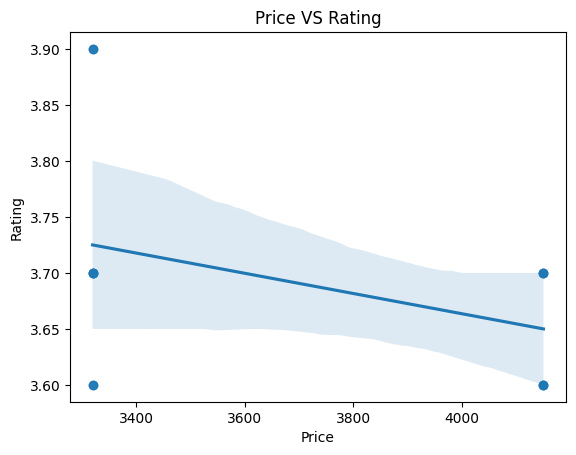

In [20]:
df['price_inr'] = pd.to_numeric(df['price_inr'], errors='coerce')

df = df[
    (df['price_inr'] < 5000) &
    (df['price_inr'] > 0) &
    (df['rating'] <= 5)
]

sns.regplot(x='price_inr', y='rating', data=df)
plt.title("Price VS Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

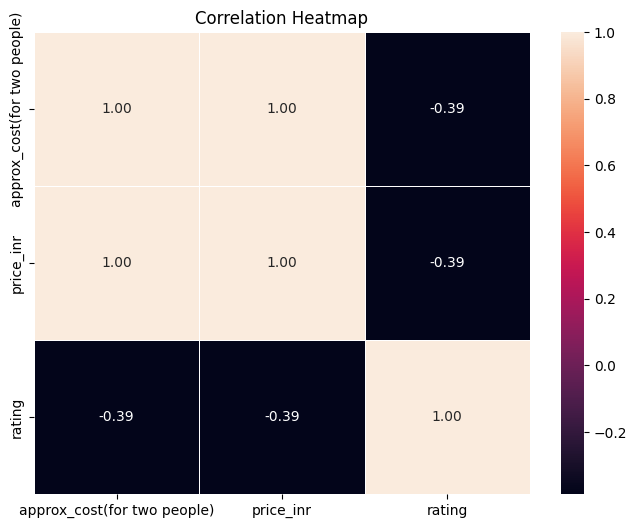

In [22]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(8,6))

sns.heatmap(df_numeric.corr(),annot=True,fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

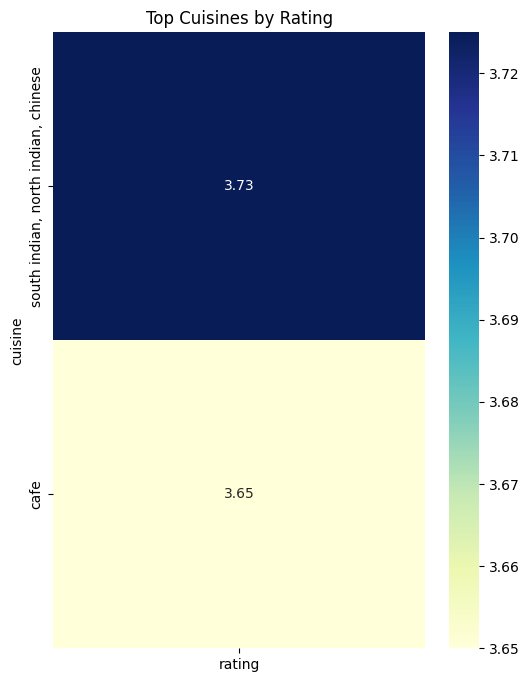

In [23]:
pivot = df.pivot_table(
    values='rating',
    index='cuisine',
    aggfunc='mean'
).sort_values(by='rating', ascending=False).head(10)

plt.figure(figsize=(6,8))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap='YlGnBu'
)

plt.title("Top Cuisines by Rating")
plt.show()

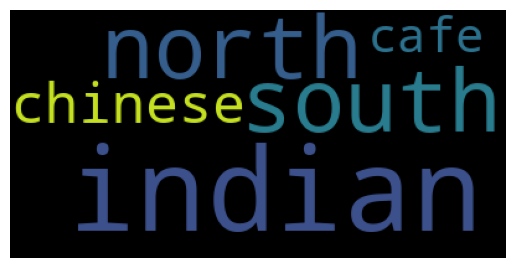

In [25]:
from wordcloud import WordCloud

text = " ".join(df['cuisine'])
wc = WordCloud().generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

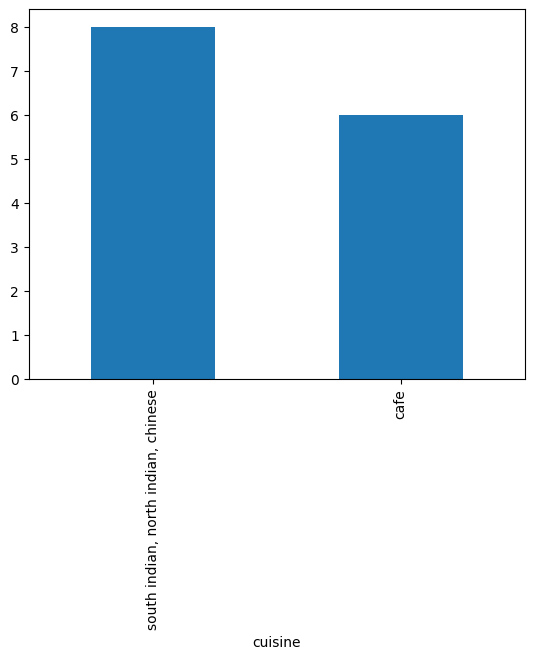

In [28]:
df['cuisine'].value_counts().head(10).plot(kind='bar')

plt.show()